In [7]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


In [8]:
circuits = pd.read_csv("f1 dataset/circuits.csv")
races = pd.read_csv("f1 dataset/races.csv")
results = pd.read_csv("f1 dataset/results.csv")
lap_times = pd.read_csv("f1 dataset/lap_times.csv")

print("Circuits shape: ", circuits.shape)
print("Races shape: ", races.shape)
print("Lap times shape: ", lap_times.shape)
print("\nCircuits sample:")
print(circuits.head())


Circuits shape:  (77, 9)
Races shape:  (1125, 18)
Lap times shape:  (589081, 6)

Circuits sample:
   circuitId   circuitRef                            name      location  \
0          1  albert_park  Albert Park Grand Prix Circuit     Melbourne   
1          2       sepang    Sepang International Circuit  Kuala Lumpur   
2          3      bahrain   Bahrain International Circuit        Sakhir   
3          4    catalunya  Circuit de Barcelona-Catalunya      Montmeló   
4          5     istanbul                   Istanbul Park      Istanbul   

     country       lat        lng  alt  \
0  Australia -37.84970  144.96800   10   
1   Malaysia   2.76083  101.73800   18   
2    Bahrain  26.03250   50.51060    7   
3      Spain  41.57000    2.26111  109   
4     Turkey  40.95170   29.40500  130   

                                                 url  
0  http://en.wikipedia.org/wiki/Melbourne_Grand_P...  
1  http://en.wikipedia.org/wiki/Sepang_Internatio...  
2  http://en.wikipedia.org/wiki/B

In [9]:
races['year'] = pd.to_numeric(races['year'], errors='coerce')

races_modern  = races[races['year'] >= 2018].copy()
races_modern.head()
races_modern.tail()
races_circuits = results.merge(
    races_modern[['raceId', 'circuitId', 'year']],
    on = 'raceId',
    how = 'inner'
)

print(races_circuits.shape)
print(races_circuits.columns)
print("Unique circuits:" , races_circuits['circuitId'].nunique())
races_circuits.head()




(2979, 20)
Index(['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid',
       'position', 'positionText', 'positionOrder', 'points', 'laps', 'time',
       'milliseconds', 'fastestLap', 'rank', 'fastestLapTime',
       'fastestLapSpeed', 'statusId', 'circuitId', 'year'],
      dtype='object')
Unique circuits: 31


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,circuitId,year
0,23782,989,20,6,5,3,1,1,1,25.0,58,1:29:33.283,5373283,53,4,1:26.469,220.782,1,1,2018
1,23783,989,1,131,44,1,2,2,2,18.0,58,+5.036,5378319,50,3,1:26.444,220.845,1,1,2018
2,23784,989,8,6,7,2,3,3,3,15.0,58,+6.309,5379592,57,2,1:26.373,221.027,1,1,2018
3,23785,989,817,9,3,8,4,4,4,12.0,58,+7.069,5380352,54,1,1:25.945,222.128,1,1,2018
4,23786,989,4,1,14,10,5,5,5,10.0,58,+27.886,5401169,57,7,1:26.978,219.489,1,1,2018


In [10]:
races_circuits['is_dnf'] = (races_circuits['statusId'] != 1).astype(int)
races_circuits['positions_gained'] = races_circuits['grid'] - races_circuits['positionOrder']

circuits_features = races_circuits.groupby("circuitId").agg(
    avg_finish_pos = ('positionOrder', 'mean'),
    finish_position_std = ('positionOrder', 'std'),
    dnf_count = ('is_dnf', 'mean'),
    avg_positions_gained = ('positions_gained', 'mean')




).reset_index()


print('Shape: ', circuits_features.shape)
print("\nColumns: ", circuits_features.columns.tolist())
print("\nSample: ")
print(circuits_features.head(10))

Shape:  (31, 5)

Columns:  ['circuitId', 'avg_finish_pos', 'finish_position_std', 'dnf_count', 'avg_positions_gained']

Sample: 
   circuitId  avg_finish_pos  finish_position_std  dnf_count  \
0          1        10.40404             5.744419   0.464646   
1          3        10.50000             5.784386   0.425000   
2          4        10.50000             5.786986   0.557143   
3          5        10.50000             5.839740   0.525000   
4          6        10.50000             5.790459   0.500000   
5          7        10.50000             5.795331   0.440000   
6          9        10.50000             5.784386   0.312500   
7         10        10.50000             5.839740   0.350000   
8         11        10.50000             5.786986   0.635714   
9         13        10.50000             5.786986   0.235714   

   avg_positions_gained  
0             -0.393939  
1             -0.068750  
2             -0.285714  
3             -0.950000  
4              0.000000  
5         

In [11]:
driver_features = results.groupby('driver_name').agg(
    avg_finish_pos = ('positionOrder', 'mean'),
    avg_grid_pos = ('grid', 'mean'),
    total_points = ('points', 'sum'),
    avg_points = ('points', 'mean'),
    total_races = ('raceId', 'count'),
    wins = ('positionOrder', lambda x: (x == 1).sum()),
    podiums = ('positionOrder', lambda x: (x <= 3).sum()),
    top10 = ('positionOrder', lambda x: (x <= 10).sum()),
    dnf_count = ('is_dnf', 'sum'),
    avg_positions_gained = ('positions_gained', 'mean'),
    finish_pos_std = ('positionOrder', 'std'),
    grid_pos_std = ('grid', 'std'),
    avg_fastestlap_rank = ('rank', 'mean'),
    avg_fastestlap_speed = ('fastestLapSpeed', 'mean')
).reset_index()

KeyError: 'driver_name'

In [12]:
races_modern.head()

,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
976,989,2018,1,1,Australian Grand Prix,2018-03-25,05:10:00,http://en.wikipedia.org/wiki/2018_Australian_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
977,990,2018,2,3,Bahrain Grand Prix,2018-04-08,15:10:00,http://en.wikipedia.org/wiki/2018_Bahrain_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
978,991,2018,3,17,Chinese Grand Prix,2018-04-15,06:10:00,http://en.wikipedia.org/wiki/2018_Chinese_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
979,992,2018,4,73,Azerbaijan Grand Prix,2018-04-29,12:10:00,http://en.wikipedia.org/wiki/2018_Azerbaijan_G...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N
980,993,2018,5,4,Spanish Grand Prix,2018-05-13,13:10:00,http://en.wikipedia.org/wiki/2018_Spanish_Gran...,\N,\N,\N,\N,\N,\N,\N,\N,\N,\N


In [13]:
races_circuits.head()

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,...,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,circuitId,year,is_dnf,positions_gained
0,23782,989,20,6,5,3,1,1,1,25.0,...,5373283,53,4,1:26.469,220.782,1,1,2018,0,2
1,23783,989,1,131,44,1,2,2,2,18.0,...,5378319,50,3,1:26.444,220.845,1,1,2018,0,-1
2,23784,989,8,6,7,2,3,3,3,15.0,...,5379592,57,2,1:26.373,221.027,1,1,2018,0,-1
3,23785,989,817,9,3,8,4,4,4,12.0,...,5380352,54,1,1:25.945,222.128,1,1,2018,0,4
4,23786,989,4,1,14,10,5,5,5,10.0,...,5401169,57,7,1:26.978,219.489,1,1,2018,0,5


In [14]:
pit_stops = pd.read_csv("f1 dataset/pit_stops.csv")
pit_stops['duration'] = pd.to_numeric(pit_stops['duration'], errors='coerce')

pit_stops_circuits = pit_stops.merge(
    races_modern[['raceId', 'circuitId']],
    on = 'raceId',
    how = 'inner'
)

avg_pit_stops = pit_stops_circuits.groupby('circuitId')['stop'].max().reset_index()
avg_pit_stops.columns = ['circuitId', 'avg_pit_stops']

print("Pit stops per circuits: ")
print(avg_pit_stops.head(10))

Pit stops per circuits: 
   circuitId  avg_pit_stops
0          1              6
1          3              6
2          4              4
3          5              3
4          6             70
5          7              4
6          9              4
7         10              6
8         11              5
9         13              3


In [15]:
from sklearn.metrics import average_precision_score
pit_stops_new = pit_stops.merge(
    races_modern[['raceId', 'circuitId']],
    on = 'raceId',
    how = 'inner'

)

stops_per_driver = pit_stops_new.groupby(['raceId', 'driverId'])['stop'].max().reset_index()
stops_per_driver.head()

stops_per_driver = stops_per_driver.merge(
    races_modern[['raceId', 'circuitId']],
    on = 'raceId',
    how='inner'
)

avg_pit_stops = stops_per_driver.groupby('circuitId')['stop'].mean().reset_index()
avg_pit_stops.columns = ['circuitId', 'avg_pit_stops']








In [16]:
# Start fresh - rebuild circuits_features cleanly
circuits_features = races_circuits.groupby("circuitId").agg(
    finish_position_std = ('positionOrder', 'std'),
    dnf_count = ('is_dnf', 'mean'),
    avg_positions_gained = ('positions_gained', 'mean')
).reset_index()

# Add average pit stops
circuits_features = circuits_features.merge(
    avg_pit_stops, on='circuitId', how='left'
)

# Add circuit names
circuits_features = circuits_features.merge(
    circuits[['circuitId', 'name', 'country']],
    on='circuitId', how='left'
)

print("Shape:", circuits_features.shape)
print("\nColumns:", circuits_features.columns.tolist())
print("\nSample:")
print(circuits_features[['name', 'country', 'finish_position_std',
                          'dnf_count', 'avg_positions_gained',
                          'avg_pit_stops']].head(10))

Shape: (31, 7)

Columns: ['circuitId', 'finish_position_std', 'dnf_count', 'avg_positions_gained', 'avg_pit_stops', 'name', 'country']

Sample:
                             name    country  finish_position_std  dnf_count  \
0  Albert Park Grand Prix Circuit  Australia             5.744419   0.464646   
1   Bahrain International Circuit    Bahrain             5.784386   0.425000   
2  Circuit de Barcelona-Catalunya      Spain             5.786986   0.557143   
3                   Istanbul Park     Turkey             5.839740   0.525000   
4               Circuit de Monaco     Monaco             5.790459   0.500000   
5       Circuit Gilles Villeneuve     Canada             5.795331   0.440000   
6             Silverstone Circuit         UK             5.784386   0.312500   
7                  Hockenheimring    Germany             5.839740   0.350000   
8                     Hungaroring    Hungary             5.786986   0.635714   
9    Circuit de Spa-Francorchamps    Belgium            

EDA

In [20]:
races_modern.head()
circuits_features.head()

,circuitId,finish_position_std,dnf_count,avg_positions_gained,avg_pit_stops,name,country
0,1,5.744419,0.464646,-0.393939,1.833333,Albert Park Grand Prix Circuit,Australia
1,3,5.784386,0.425000,-0.068750,2.337662,Bahrain International Circuit,Bahrain
2,4,5.786986,0.557143,-0.285714,1.985185,Circuit de Barcelona-Catalunya,Spain
3,5,5.839740,0.525000,-0.950000,1.487179,Istanbul Park,Turkey
4,6,5.790459,0.500000,0.000000,4.079646,Circuit de Monaco,Monaco


In [28]:
print("Shape: ", circuits_features.shape)
circuits_features.head()
print("\nNull numbers: ", circuits_features.isnull().sum())
circuits_features.describe()

Shape:  (31, 7)

Null numbers:  circuitId               0
finish_position_std     0
dnf_count               0
avg_positions_gained    0
avg_pit_stops           0
name                    0
country                 0
dtype: int64


,circuitId,finish_position_std,dnf_count,avg_positions_gained,avg_pit_stops
count,31.000000,31.000000,31.000000,31.000000,31.000000
mean,34.612903,5.807033,0.423079,-0.404411,2.012794
std,29.546209,0.035446,0.125508,0.310382,0.789439
min,1.000000,5.744419,0.133333,-1.125000,1.184211
25%,10.500000,5.786986,0.350000,-0.570000,1.480076
50%,21.000000,5.795331,0.425000,-0.383333,1.794872
75%,70.500000,5.814943,0.484286,-0.250000,2.105533
max,80.000000,5.916080,0.635714,0.000000,4.714286


## EDA Observations — Basic Statistics

### Feature Usefulness Assessment:
- finish_position_std → LOW usefulness 
  (range only 0.17, barely varies between circuits)
- dnf_count → MEDIUM usefulness 
  (range 0.50, meaningful differences between circuits)
- avg_positions_gained → MEDIUM usefulness 
  (range 1.125, captures overtaking difficulty)
- avg_pit_stops → HIGH usefulness 
  (range 3.53, largest variation between circuits)

### No missing values — data is clean ✅
### 31 circuits — small dataset, 
    need to be careful with number of clusters

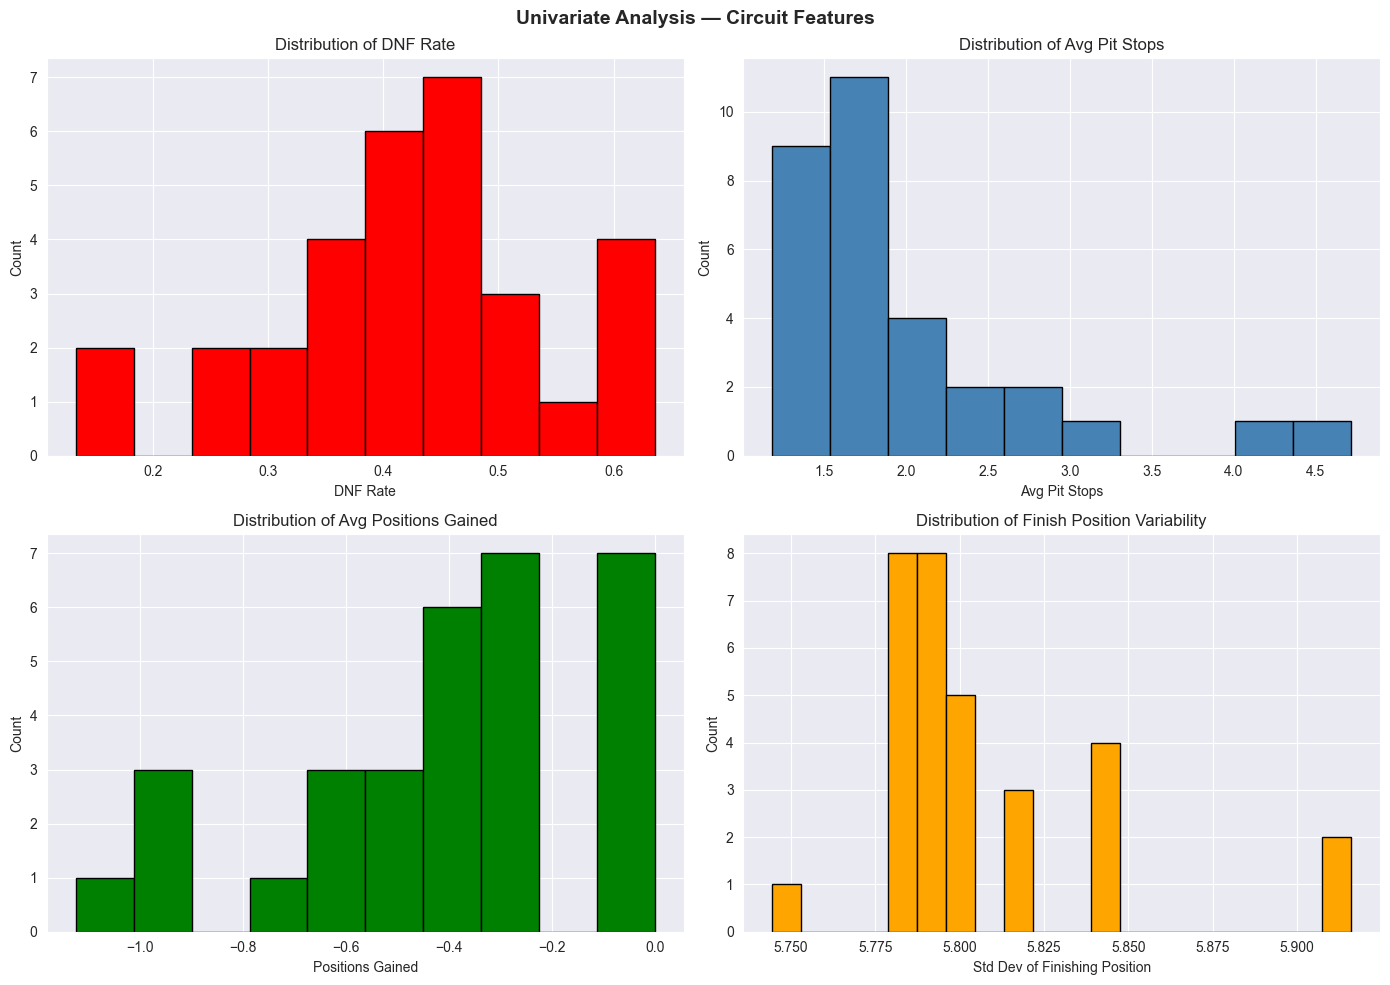

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.set_style("darkgrid")

# DNF Rate
axes[0,0].hist(circuits_features['dnf_count'],
               bins=10, color='red', edgecolor='black')
axes[0,0].set_title('Distribution of DNF Rate')
axes[0,0].set_xlabel('DNF Rate')
axes[0,0].set_ylabel('Count')

# Avg Pit Stops
axes[0,1].hist(circuits_features['avg_pit_stops'],
               bins=10, color='steelblue', edgecolor='black')
axes[0,1].set_title('Distribution of Avg Pit Stops')
axes[0,1].set_xlabel('Avg Pit Stops')
axes[0,1].set_ylabel('Count')

# Positions Gained
axes[1,0].hist(circuits_features['avg_positions_gained'],
               bins=10, color='green', edgecolor='black')
axes[1,0].set_title('Distribution of Avg Positions Gained')
axes[1,0].set_xlabel('Positions Gained')
axes[1,0].set_ylabel('Count')

# Finish Position Std - use more bins since range is small
axes[1,1].hist(circuits_features['finish_position_std'],
               bins=20, color='orange', edgecolor='black')
axes[1,1].set_title('Distribution of Finish Position Variability')
axes[1,1].set_xlabel('Std Dev of Finishing Position')
axes[1,1].set_ylabel('Count')

plt.suptitle('Univariate Analysis — Circuit Features',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

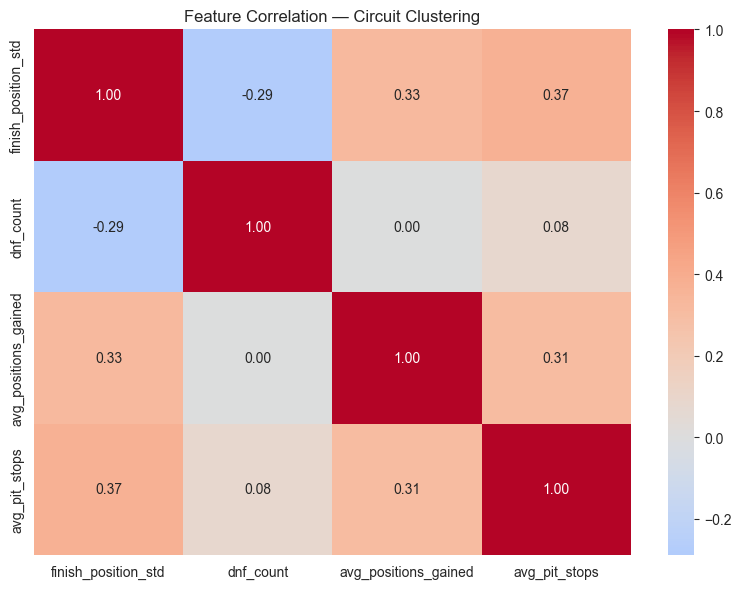

                      finish_position_std  dnf_count  avg_positions_gained  \
finish_position_std              1.000000  -0.288681              0.329846   
dnf_count                       -0.288681   1.000000              0.000496   
avg_positions_gained             0.329846   0.000496              1.000000   
avg_pit_stops                    0.371907   0.078854              0.309409   

                      avg_pit_stops  
finish_position_std        0.371907  
dnf_count                  0.078854  
avg_positions_gained       0.309409  
avg_pit_stops              1.000000  


In [37]:
corr = circuits_features[['finish_position_std', 
                           'dnf_count',
                           'avg_positions_gained',
                           'avg_pit_stops']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', 
            cmap='coolwarm', center=0)
plt.title('Feature Correlation — Circuit Clustering')
plt.tight_layout()
plt.show()

print(corr)

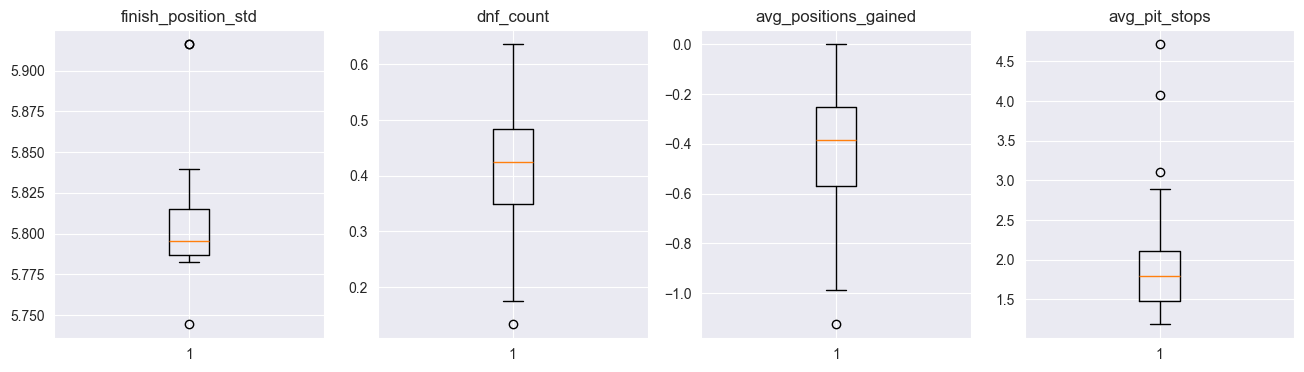

In [39]:
fig, axes = plt.subplots(1,4, figsize=(16,4))
features = ['finish_position_std', 'dnf_count', 'avg_positions_gained', 'avg_pit_stops']

for i, col in enumerate(features):
    axes[i].boxplot(circuits_features[col])
    axes[i].set_title(col)

In [40]:
circuits_features[circuits_features['avg_pit_stops']>3]

,circuitId,finish_position_std,dnf_count,avg_positions_gained,avg_pit_stops,name,country
4,6,5.790459,0.50,0.0,4.079646,Circuit de Monaco,Monaco
7,10,5.839740,0.35,0.0,3.105263,Hockenheimring,Germany
26,76,5.916080,0.40,0.0,4.714286,Autodromo Internazionale del Mugello,Italy


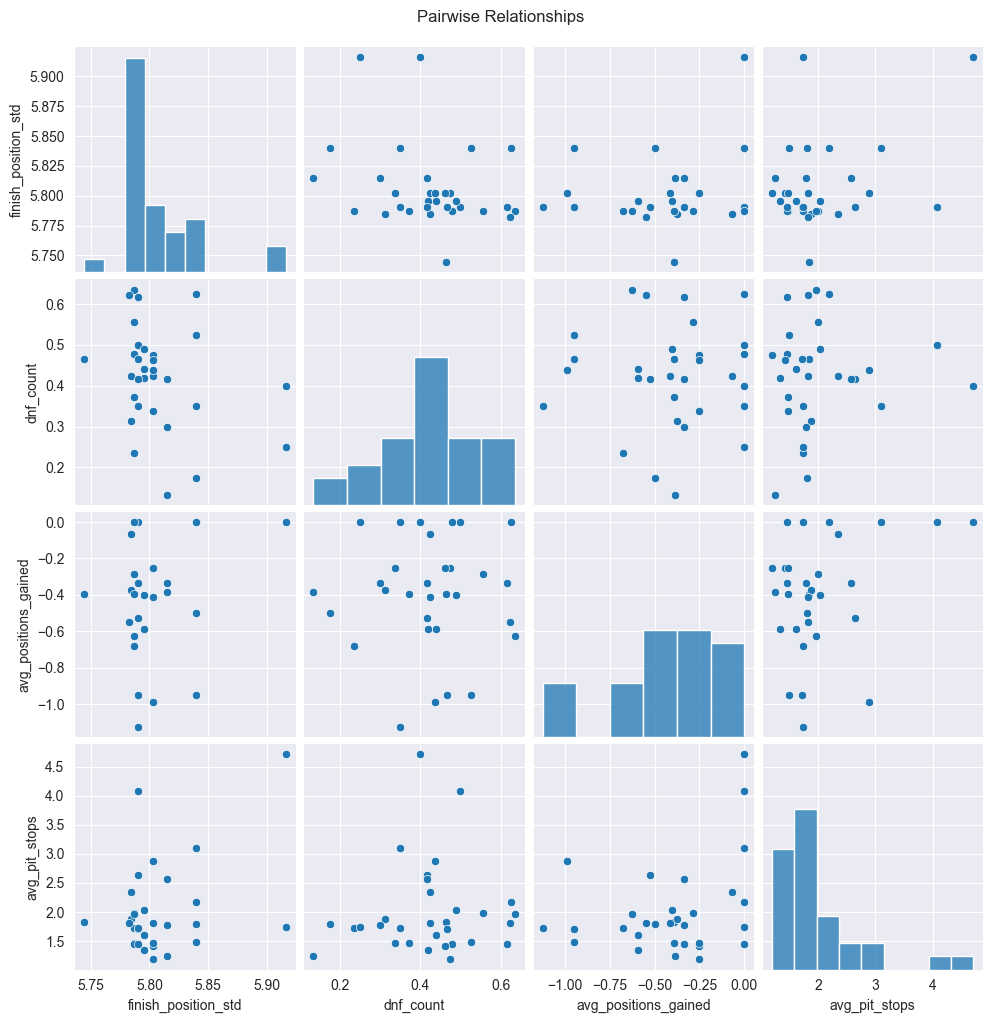

In [42]:
sns.pairplot(circuits_features[features])
plt.suptitle("Pairwise Relationships", y=1.02)
plt.show()

In [49]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_features = scaler.fit_transform(circuits_features[features])
scaled_features


array([[-1.79565207,  0.33667144,  0.03429502, -0.23108493],
       [-0.64948402,  0.01556116,  1.09931912,  0.41831993],
       [-0.57491224,  1.08583139,  0.38874184, -0.0355512 ],
       [ 0.93796773,  0.82549538, -1.78685277, -0.67681378],
       [-0.47532657,  0.62301183,  1.32448146,  2.66140459],
       [-0.33560497,  0.13705129, -0.60782085, -0.52877002],
       [-0.64948402, -0.89561485,  0.09632321, -0.18178259],
       [ 0.93796773, -0.59188951,  1.32448146,  1.40672966],
       [-0.57491224,  1.72220828, -0.7341457 , -0.06524978],
       [-0.57491224, -1.51752863, -0.89790013, -0.3622356 ],
       [-0.57491224, -0.41833218,  0.03783949, -0.70453793],
       [-0.33560497, -0.02493555, -0.60782085, -0.87025005],
       [ 0.22682914, -0.99685663,  0.23278524, -0.29546798],
       [-0.47532657, -0.05193336, -0.39494009,  0.79981044],
       [ 3.12724209, -1.40182374,  1.32448146, -0.35533293],
       [-0.12535972,  0.01556116, -0.02649261, -0.25367547],
       [-0.33560497,  0.

Apply the Elbow method

AttributeError: Line2D.set() got an unexpected keyword argument 'markers'

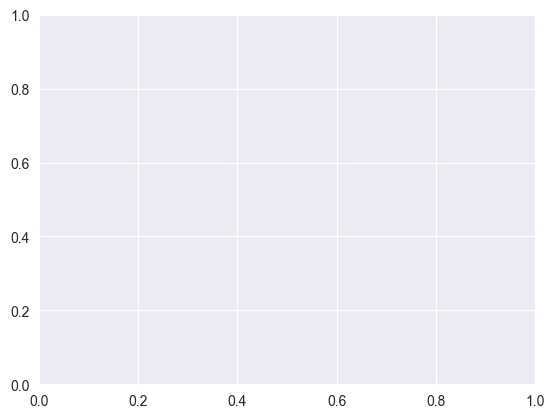

In [50]:
from sklearn.cluster import KMeans
inertias = []
for k in range(2,8):
    km = KMeans(n_clusters=k, random_state=42, n_init = 10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.plot(range(2,8), inertias, markers = 'o')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title("Elbow Method")
plt.show()